# IMDB Sentiment Analysis with Word Embeddings

Binary classification of movie reviews (positive vs. negative) using the raw IMDB text corpus. The pipeline compares pre-trained GloVe embeddings against task-tuned embeddings, evaluates embedding quality with sentiment word lists, and builds a dual-branch (Y-network) LSTM + Conv1D model.

**Goal:** exceed 90% test accuracy through embedding fine-tuning, architecture search, and staged training.

## Data Requirements

Place the following in the working directory:
- `aclImdb/` (IMDB review corpus)
- `glove.6B.300d.txt` (GloVe 300-d vectors)
- `positive.txt` / `negative.txt` (sentiment lexicons)


In [ ]:
from tensorflow import keras
keras.__version__


'3.10.0'

## 2. Sentiment Lexicons

Load curated lists of positive and negative words used to evaluate embedding quality.

In [ ]:
filepath = 'positive.txt'
L_pos = []
with open(filepath) as fp:
    line = fp.readline()
    cnt = 1
    while line:
        if cnt > 35:
            L_pos.append(line.strip())
        line = fp.readline()
        cnt += 1
for word in L_pos:
    print(word)
print(len(L_pos))


a+
abound
abounds
abundance
abundant
accessable
accessible
acclaim
acclaimed
acclamation
accolade
accolades
accommodative
accomodative
accomplish
accomplished
accomplishment
accomplishments
accurate
accurately
achievable
achievement
achievements
achievible
acumen
adaptable
adaptive
adequate
adjustable
admirable
admirably
admiration
admire
admirer
admiring
admiringly
adorable
adore
adored
adorer
adoring
adoringly
adroit
adroitly
adulate
adulation
adulatory
advanced
advantage
advantageous
advantageously
advantages
adventuresome
adventurous
advocate
advocated
advocates
affability
affable
affably
affectation
affection
affectionate
affinity
affirm
affirmation
affirmative
affluence
affluent
afford
affordable
affordably
afordable
agile
agilely
agility
agreeable
agreeableness
agreeably
all-around
alluring
alluringly
altruistic
altruistically
amaze
amazed
amazement
amazes
amazing
amazingly
ambitious
ambitiously
ameliorate
amenable
amenity
amiability
amiabily
amiable
amicability
amicable
amicabl

In [ ]:
filepath = 'negative.txt'
L_neg = []
with open(filepath) as fp:
    line = fp.readline()
    cnt = 1
    while line:
        if cnt > 35:
            L_neg.append(line.strip())
        line = fp.readline()
        cnt += 1
for word in L_neg:
    print(word)
print(len(L_neg))


2-faced
2-faces
abnormal
abolish
abominable
abominably
abominate
abomination
abort
aborted
aborts
abrade
abrasive
abrupt
abruptly
abscond
absence
absent-minded
absentee
absurd
absurdity
absurdly
absurdness
abuse
abused
abuses
abusive
abysmal
abysmally
abyss
accidental
accost
accursed
accusation
accusations
accuse
accuses
accusing
accusingly
acerbate
acerbic
acerbically
ache
ached
aches
achey
aching
acrid
acridly
acridness
acrimonious
acrimoniously
acrimony
adamant
adamantly
addict
addicted
addicting
addicts
admonish
admonisher
admonishingly
admonishment
admonition
adulterate
adulterated
adulteration
adulterier
adversarial
adversary
adverse
adversity
afflict
affliction
afflictive
affront
afraid
aggravate
aggravating
aggravation
aggression
aggressive
aggressiveness
aggressor
aggrieve
aggrieved
aggrivation
aghast
agonies
agonize
agonizing
agonizingly
agony
aground
ail
ailing
ailment
aimless
alarm
alarmed
alarming
alarmingly
alienate
alienated
alienation
allegation
allegations
allege
aller

## 3. Word Embeddings Overview

Two strategies: learn embeddings jointly with the classifier, or initialize from pre-trained vectors (GloVe) and optionally fine-tune.

### 3.1 Learning Embeddings In-Task

Random initialization works when enough data is available — the network learns structure during training.

### 3.2 Pre-Trained Embeddings (GloVe)

When data is limited, import 300-d GloVe vectors trained on 6B tokens to bootstrap semantic structure.

### 3.3 End-to-End Pipeline

Download raw IMDB reviews, tokenize, map to GloVe vectors, and train a classifier on top.

## 4. Load IMDB Reviews

Read all training reviews as raw text strings with binary labels.

In [ ]:
import os
imdb_dir = 'aclImdb'
train_dir = os.path.join(imdb_dir, 'train')
labels = []
texts = []
for label_type in ['neg', 'pos']:
    dir_name = os.path.join(train_dir, label_type)
    for fname in os.listdir(dir_name):
        if fname[-4:] == '.txt':
            f = open(os.path.join(dir_name, fname))
            texts.append(f.read())
            f.close()
            if label_type == 'neg':
                labels.append(0)
            else:
                labels.append(1)


In [ ]:
texts[:2]


['Warner Bros. made many potboilers in the 1930s and most of them are fast paced, economical and very entertaining. I really love how the studio exploited the less glamorous elements of our daily life. This is one of Warner\'s few hard-edged melodramas that simply doesn\'t work. Edward G. Robinson plays a ruthless editor of newspaper who resurrects the 20-year old story of a murderess with tragic consequences. Robinson gives a lively performance but he is surrounded by actors that don\'t cut the mustard. H.B. Warner, Aline MacMahon and Boris Karloff are good, but the bad acting of Frances Starr and Anthony Bushell in the second leads really hurts the movie. Starr is particularly bad during her big dramatic scene near the end of the movie. In addition, the moralistic tone of the film seems ridiculous in the context of pre-code Hollywood. LeRoy\'s direction is full of innovative visual touches but he cannot overcome the bad acting and the unintentionally funny situations. Sol Polito\'s c

In [ ]:
labels[:2]


[0, 0]

In [ ]:
len(labels)


25000

## 5. Tokenization

Convert text to padded integer sequences. Shuffle before splitting into 80/20 train/validation.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
maxlen = 500
training_samples = 20000
validation_samples = 5000
max_words = 10000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))
data = pad_sequences(sequences, maxlen=maxlen)
labels = np.asarray(labels)
print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', labels.shape)
indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]
x_train = data[:training_samples]
y_train = labels[:training_samples]
x_val = data[training_samples: training_samples + validation_samples]
y_val = labels[training_samples: training_samples + validation_samples]


Found 88582 unique tokens.
Shape of data tensor: (25000, 500)
Shape of label tensor: (25000,)


In [ ]:
word_index


{'the': 1,
 'and': 2,
 'a': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'br': 7,
 'in': 8,
 'it': 9,
 'i': 10,
 'this': 11,
 'that': 12,
 'was': 13,
 'as': 14,
 'for': 15,
 'with': 16,
 'movie': 17,
 'but': 18,
 'film': 19,
 'on': 20,
 'not': 21,
 'you': 22,
 'are': 23,
 'his': 24,
 'have': 25,
 'he': 26,
 'be': 27,
 'one': 28,
 'all': 29,
 'at': 30,
 'by': 31,
 'an': 32,
 'they': 33,
 'who': 34,
 'so': 35,
 'from': 36,
 'like': 37,
 'her': 38,
 'or': 39,
 'just': 40,
 'about': 41,
 "it's": 42,
 'out': 43,
 'has': 44,
 'if': 45,
 'some': 46,
 'there': 47,
 'what': 48,
 'good': 49,
 'more': 50,
 'when': 51,
 'very': 52,
 'up': 53,
 'no': 54,
 'time': 55,
 'she': 56,
 'even': 57,
 'my': 58,
 'would': 59,
 'which': 60,
 'only': 61,
 'story': 62,
 'really': 63,
 'see': 64,
 'their': 65,
 'had': 66,
 'can': 67,
 'were': 68,
 'me': 69,
 'well': 70,
 'than': 71,
 'we': 72,
 'much': 73,
 'been': 74,
 'bad': 75,
 'get': 76,
 'will': 77,
 'do': 78,
 'also': 79,
 'into': 80,
 'people': 81,
 'other': 82,
 '

In [ ]:
data.shape


(25000, 500)

## 6. Load GloVe Embeddings

Parse `glove.6B.300d.txt` into a word → vector dictionary.

In [ ]:
glove_dir = '.'
embeddings_index = {}
f = open(os.path.join(glove_dir, 'glove.6B.300d.txt'))
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()
print('Found %s word vectors.' % len(embeddings_index))


Found 400000 word vectors.


Build the embedding matrix (`max_words × 300`) mapping tokenizer indices to GloVe vectors. Index 0 is reserved for padding/unknown.

In [ ]:
embedding_dim = 300
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < max_words:
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


Filter positive/negative lexicon words to those present in both GloVe and the tokenizer vocabulary.

In [ ]:
L_POS = []
for word in L_pos:
    if word in embeddings_index and word in word_index and word_index[word] < max_words:
        L_POS.append(word)
L_NEG = []
for word in L_neg:
    if word in embeddings_index and word in word_index and word_index[word] < max_words:
        L_NEG.append(word)
len(L_POS), len(L_NEG)


(706, 1164)

Most frequent positive sentiment words (by token index) in the vocabulary.

In [ ]:
top_pos = sorted(L_POS, key=lambda w: word_index[w])[:100]
print(top_pos)


['like', 'good', 'well', 'great', 'best', 'love', 'better', 'work', 'pretty', 'enough', 'right', 'interesting', 'fun', 'worth', 'beautiful', 'excellent', 'nice', 'top', 'classic', 'enjoy', 'recommend', 'wonderful', 'perfect', 'liked', 'entertaining', 'loved', 'fans', 'fine', 'amazing', 'humor', 'lead', 'works', 'enjoyed', 'favorite', 'brilliant', 'decent', 'strong', 'wonder', 'hero', 'hilarious', 'cool', 'happy', 'important', 'talent', 'modern', 'clearly', 'supporting', 'fast', 'romantic', 'enjoyable', 'easy', 'fantastic', 'clear', 'famous', 'realistic', 'leads', 'greatest', 'believable', 'free', 'hot', 'superb', 'memorable', 'beauty', 'perfectly', 'worked', 'incredibly', 'leading', 'powerful', 'masterpiece', 'fairly', 'talented', 'success', 'rich', 'cute', 'sweet', 'incredible', 'pure', 'popular', 'convincing', 'intelligent', 'clever', 'successful', 'positive', 'exciting', 'effective', 'amusing', 'appreciate', 'solid', 'impressive', 'respect', 'super', 'win', 'recommended', 'awesome',

Most frequent negative sentiment words (by token index) in the vocabulary.

In [ ]:
top_neg = sorted(L_NEG, key=lambda w: word_index[w])[:100]
print(top_neg)


['bad', 'plot', 'funny', 'worst', 'hard', 'poor', 'death', 'dead', 'wrong', 'boring', 'awful', 'stupid', 'terrible', 'lost', 'worse', 'waste', 'problem', 'evil', 'killer', 'dark', 'unfortunately', 'kill', 'horrible', 'slow', 'killed', 'lack', 'murder', 'crap', 'hell', 'annoying', 'sad', 'scary', 'ridiculous', 'strange', 'disappointed', 'cheap', 'silly', 'problems', 'miss', 'falls', 'mystery', 'dull', 'hate', 'die', 'sorry', 'fall', 'weak', 'crime', 'doubt', 'lame', 'poorly', 'zombie', 'difficult', 'killing', 'shame', 'badly', 'weird', 'crazy', 'creepy', 'mess', 'cheesy', 'monster', 'joke', 'break', 'dumb', 'fails', 'twist', 'odd', 'sadly', 'cold', 'missed', 'wasted', 'revenge', 'tension', 'fear', 'kills', 'bored', 'trouble', 'violent', 'died', 'pointless', 'trash', 'bizarre', 'impossible', 'mad', 'prison', 'sick', 'disturbing', 'failed', 'fake', 'fiction', 'pathetic', 'garbage', 'utterly', 'attack', 'loud', 'unbelievable', 'twists', 'complex', 'laughable']


## 7. Baseline Model (Frozen GloVe)

Embedding → Flatten → Dense classifier. GloVe weights are frozen.

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense
assert embedding_matrix.shape == (max_words, embedding_dim), "embedding_matrix shape is incorrect."
model = Sequential()
model.add(Embedding(input_dim=max_words,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


Load pre-computed GloVe weights into the Embedding layer.

### Train & Evaluate Baseline

In [ ]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.5918 - loss: 0.7492 - val_acc: 0.7562 - val_loss: 0.5113
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8565 - loss: 0.3472 - val_acc: 0.7694 - val_loss: 0.5234
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.9340 - loss: 0.1847 - val_acc: 0.7678 - val_loss: 0.6452
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9709 - loss: 0.0914 - val_acc: 0.7592 - val_loss: 0.8270
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9852 - loss: 0.0475 - val_acc: 0.7422 - val_loss: 1.1596
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9913 - loss: 0.0278 - val_acc: 0.7508 - val_loss: 1.2166
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9928 - loss: 0.0195 - val_acc: 0.7412 - val_loss: 1.4740
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9954 - loss: 0.0138 - val_acc: 0.7362 - val_loss: 1.7657
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - ac

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
def plot_history(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.figure()
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()


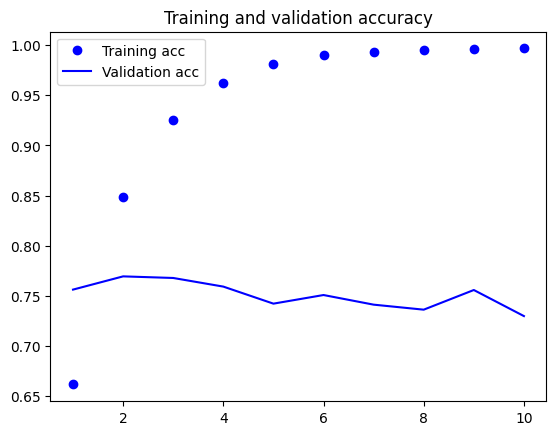

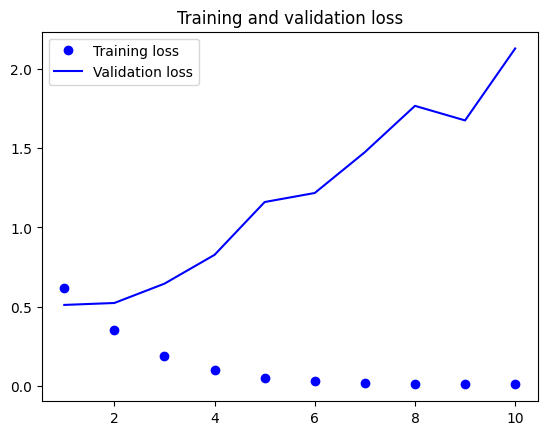

In [ ]:
plot_history(history)


## 8. Fine-Tuned Dense Model

Unfreeze the embedding layer and retrain jointly with the dense head.

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense
assert embedding_matrix.shape == (max_words, embedding_dim), "embedding_matrix shape is incorrect."
model = Sequential()
model.add(Embedding(input_dim=max_words,
                    output_dim=embedding_dim,
                    input_length=maxlen,
                    weights=[embedding_matrix],
                    trainable=True))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - acc: 0.6134 - loss: 0.8336 - val_acc: 0.7680 - val_loss: 0.4857
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - acc: 0.8846 - loss: 0.2872 - val_acc: 0.7914 - val_loss: 0.5245
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - acc: 0.9687 - loss: 0.0973 - val_acc: 0.8026 - val_loss: 0.6122
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - acc: 0.9925 - loss: 0.0275 - val_acc: 0.8060 - val_loss: 0.7873
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - acc: 0.9972 - loss: 0.0101 - val_acc: 0.8060 - val_loss: 0.9404
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - acc: 0.9986 - loss: 0.0039 - val_acc: 0.8100 - val_loss: 1.1198
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - acc: 0.9988 - loss: 0.0022 - val_acc: 0.8072 - val_loss: 1.2641
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - acc: 0.9993 - loss: 9.7830e-04 - val_acc: 0.8072 - val_loss: 1.5268
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20m

Training curves for the dense model.

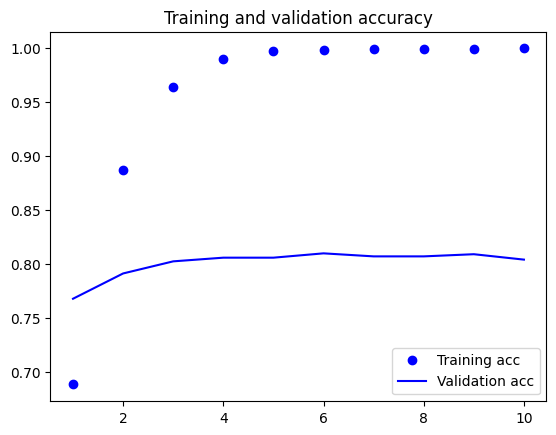

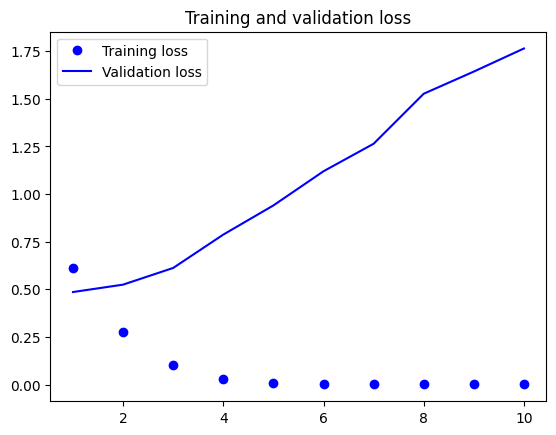

In [ ]:
plot_history(history)


In [ ]:
embedding_matrix1 = model.layers[0].get_weights()[0]


## 9. LSTM Model

Replace Flatten+Dense with an LSTM layer to capture word order in reviews.

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense
assert embedding_matrix.shape == (max_words, embedding_dim), "embedding_matrix shape is incorrect."
model = Sequential()
model.add(Embedding(input_dim=max_words,
                    output_dim=embedding_dim,
                    input_length=maxlen,
                    weights=[embedding_matrix],
                    trainable=True))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - acc: 0.6980 - loss: 0.5643 - val_acc: 0.8540 - val_loss: 0.3514
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - acc: 0.8659 - loss: 0.3304 - val_acc: 0.8850 - val_loss: 0.2834
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - acc: 0.9106 - loss: 0.2302 - val_acc: 0.8908 - val_loss: 0.2726
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - acc: 0.9327 - loss: 0.1780 - val_acc: 0.8924 - val_loss: 0.2725
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - acc: 0.9545 - loss: 0.1323 - val_acc: 0.8960 - val_loss: 0.2968
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - acc: 0.9686 - loss: 0.0966 - val_acc: 0.8958 - val_loss: 0.3159
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - acc: 0.9786 - loss: 0.0716 - val_acc: 0.8918 - val_loss: 0.3688
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - acc: 0.9866 - loss: 0.0472 - val_acc: 0.8774 - val_loss: 0.4744
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

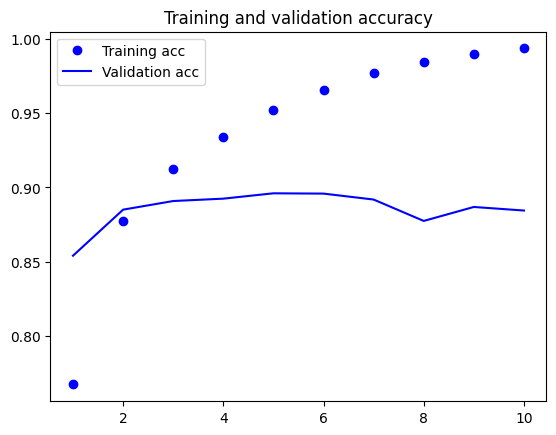

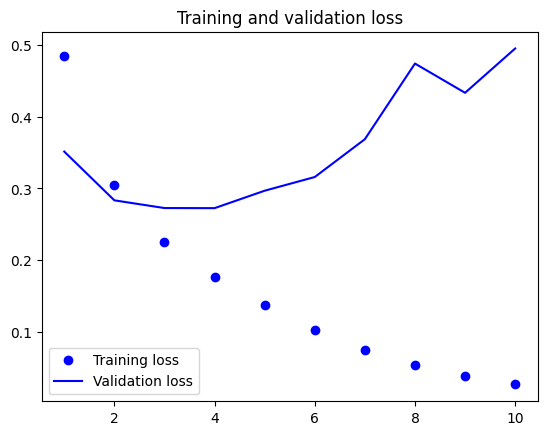

In [ ]:
plot_history(history)


In [ ]:
embedding_matrix2 = model.layers[0].get_weights()[0]


In [ ]:
embedding_matrix2.shape


(10000, 300)

## 10. Embedding Comparison — Word Distance

Cosine distance between word pairs across GloVe, dense-tuned, and LSTM-tuned embeddings.

In [ ]:
def word_dist(word1, word2, embedding_matrix):
    if (word1 not in word_index) or (word2 not in word_index):
        return None
    idx1, idx2 = word_index[word1], word_index[word2]
    if idx1 >= max_words or idx2 >= max_words:
        return None
    vec1 = embedding_matrix[idx1]
    vec2 = embedding_matrix[idx2]
    num = np.dot(vec1, vec2)
    denom = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    if denom == 0:
        return None
    cosine_sim = num / denom
    cosine_dist = 1 - cosine_sim
    return cosine_dist
def dist_glove(word1, word2):
    return word_dist(word1, word2, embedding_matrix)
def dist_dense(word1, word2):
    return word_dist(word1, word2, embedding_matrix1)
def dist_LSTM(word1, word2):
    return word_dist(word1, word2, embedding_matrix2)


Compare whether fine-tuned embeddings place antonyms farther apart than unrelated word pairs.

In [ ]:
print(dist_glove('better', 'worse') < dist_glove('worst', 'worse'))
print(dist_dense('better', 'worse') < dist_dense('worst', 'worse'))
print(dist_LSTM('better', 'worse') < dist_LSTM('worst', 'worse'))


True
False
False


In [ ]:
print(dist_glove('good', 'bad') < dist_glove('poor', 'bad'))
print(dist_dense('good', 'bad') < dist_dense('poor', 'bad'))
print(dist_LSTM('good', 'bad') < dist_LSTM('poor', 'bad'))


True
False
True


In [ ]:
print(dist_glove('bad', 'good') < dist_glove('great', 'good'))
print(dist_dense('bad', 'good') < dist_dense('great', 'good'))
print(dist_LSTM('bad', 'good') < dist_LSTM('great', 'good'))


True
False
False


In [ ]:
print(dist_glove('clever', 'clumsy') < dist_glove('clever', 'ingenious'))
print(dist_dense('clever', 'clumsy') < dist_dense('clever', 'ingenious'))
print(dist_LSTM('clever', 'clumsy') < dist_LSTM('clever', 'ingenious'))


False
False
False


## 11. Nearest-Neighbor Analysis

For each embedding space, find the closest vocabulary word by cosine similarity.

In [ ]:
def NN_general(word, embedding_matrix):
    if word not in word_index:
        return None
    idx = word_index[word]
    if idx >= max_words:
        return None
    target_vec = embedding_matrix[idx]
    normed = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)
    target_norm = target_vec / np.linalg.norm(target_vec)
    sims = np.dot(normed, target_norm)
    sims[idx] = -1
    nearest_idx = np.argmax(sims)
    inv_index = {v: k for k, v in word_index.items() if v < max_words}
    nearest_word = inv_index.get(nearest_idx, None)
    return nearest_word
def NN_LSTM(word):
    return NN_general(word, embedding_matrix2)
def NN_dense(word):
    return NN_general(word, embedding_matrix1)
def NN_glove(word):
    return NN_general(word, embedding_matrix)


In [ ]:
EPS = 1e-10
max_idx = max_words
inv_index = np.array([None]*max_idx, dtype=object)
for w, i in word_index.items():
    if i < max_idx:
        inv_index[i] = w
def precompute_normed(M):
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    N = M / norms
    mask = (np.linalg.norm(M, axis=1) > EPS)
    return N, mask
norm_glove, mask_glove = precompute_normed(embedding_matrix)
norm_dense, mask_dense = precompute_normed(embedding_matrix1)
norm_lstm,  mask_lstm  = precompute_normed(embedding_matrix2)
def NN_general(word, normed, mask):
    idx = word_index.get(word)
    if idx is None or idx >= max_idx or not mask[idx]:
        return None
    if word not in word_index or word_index[word] >= max_words:
        return None
    sims = normed @ normed[idx]
    sims[~mask] = -1e9
    sims[0] = -1e9
    sims[idx] = -1e9
    j = int(np.argmax(sims))
    return inv_index[j]
def NN_glove(w): return NN_general(w, norm_glove, mask_glove)
def NN_dense(w): return NN_general(w, norm_dense, mask_dense)
def NN_LSTM(w):  return NN_general(w, norm_lstm,  mask_lstm)


Words whose LSTM nearest neighbor differs from GloVe but matches dense.

In [ ]:
count = 0
for word in L_POS + L_NEG:
    if NN_LSTM(word) != NN_glove(word) and NN_dense(word) == NN_glove(word):
        print('::::', word, NN_LSTM(word), NN_glove(word))
        count += 1
print(count, 'changes', 'out of', len(L_POS) + len(L_NEG))


:::: admirer admiration avid
:::: awe inspiring disbelief
:::: bonus extra cd
:::: catchy snappy tunes
:::: credible plausible reliable
:::: decency morality fairness
:::: delightful lovely charming
:::: fantastically wonderfully unbelievably
:::: fine well art
:::: fresh bring amid
:::: hardy winters bloom
:::: healthy eating stable
:::: helped help helping
:::: honest truthful straightforward
:::: improve improved enhance
:::: loyal followers faithful
:::: luck lucky good
:::: mighty beast big
:::: modest substantial relatively
:::: notably including particularly
:::: openly gays criticize
:::: peaceful peace calm
:::: pleasantly delightfully amazed
:::: promised promises promise
:::: restored converted built
:::: right back left
:::: suave dashing seductive
:::: valuable useful precious
:::: wonderfully delightfully beautifully
:::: alarm alert warning
:::: annoyingly amusingly cliched
:::: assassin murderer killer
:::: bash celebration birthday
:::: bland dull boring
:::: brainless

Words whose dense nearest neighbor differs from GloVe but matches LSTM.

In [ ]:
count = 0
for word in L_POS + L_NEG:
    if NN_dense(word) != NN_glove(word) and NN_LSTM(word) == NN_glove(word):
        print('::::', word, NN_dense(word), NN_glove(word))
        count += 1
print(count, 'changes', 'out of', len(L_POS) + len(L_NEG))


:::: better even good
:::: encourage encouraged promote
:::: fantastic amazing incredible
:::: fun enjoyable stuff
:::: gorgeous lovely beautiful
:::: nice lovely wonderful
:::: perfect wonderful ideal
:::: perfection simplicity perfect
:::: poignant hilarious haunting
:::: satisfy fulfill desires
:::: sweet flavor delicious
:::: wonderful amazing terrific
:::: anxious worried eager
:::: boring dull tedious
:::: confusion anxiety chaos
:::: cruel sadistic brutal
:::: doomed unfortunately fail
:::: drain dry pour
:::: evil villain wicked
:::: fear fears worry
:::: haunting poignant eerie
:::: ignorant stupid naive
:::: kills destroys killed
:::: liar cheat thief
:::: mess awful messy
:::: slow slower pace
:::: stricken disaster survivors
:::: toxic wastes waste
:::: trouble difficulty problems
29 changes out of 1870


In [ ]:
count = 0
for word in L_POS + L_NEG:
    if NN_LSTM(word) != NN_dense(word) and NN_dense(word) != NN_glove(word) and NN_LSTM(word) != NN_glove(word):
        print('::::', word, NN_glove(word), NN_dense(word), NN_LSTM(word))
        count += 1
print(count)


:::: angel gabriel jose lopez
:::: good better always well
:::: crap stuff woman's freaking
:::: poor poverty bad lack
:::: wrong think something why
5


Words where dense and LSTM agree on nearest neighbor but GloVe disagrees.

In [ ]:
count = 0
for word in L_POS + L_NEG:
    if NN_LSTM(word) == NN_dense(word) and NN_dense(word) != NN_glove(word):
        print('::::', word, NN_glove(word), NN_dense(word), NN_LSTM(word))
        count += 1
print(count)


:::: best better well well
:::: clear yet clearly clearly
:::: convenient easy easier easier
:::: decent good respectable respectable
:::: educated college studied studied
:::: enough so needed needed
:::: excellent good superb superb
:::: extraordinarily incredibly exceedingly exceedingly
:::: fascinating interesting intriguing intriguing
:::: flashy stylish flamboyant flamboyant
:::: free freedom without without
:::: friendly ties relations relations
:::: genius geniuses brilliant brilliant
:::: kudos deserves acclaim acclaim
:::: outstanding achievement exceptional exceptional
:::: powerful potent strong strong
:::: realistic unrealistic realistically realistically
:::: solid consistent strong strong
:::: stable healthy relatively relatively
:::: superb brilliant excellent excellent
:::: winning won win win
:::: abomination unforgivable monstrosity monstrosity
:::: annoyance embarrassment frustration frustration
:::: bad good worse worse
:::: bored tired boring boring
:::: comical h

Words where all three embedding spaces agree on nearest neighbor.

In [ ]:
count = 0
for word in L_POS + L_NEG:
    if NN_LSTM(word) == NN_dense(word) and NN_dense(word) == NN_glove(word):
        print('::::', word, NN_glove(word), NN_dense(word), NN_LSTM(word))
        count += 1
print(count)


:::: abound plenty plenty plenty
:::: abundance diversity diversity diversity
:::: accessible access access access
:::: acclaim garnered garnered garnered
:::: acclaimed renowned renowned renowned
:::: accomplish achieve achieve achieve
:::: accomplished accomplish accomplish accomplish
:::: accomplishment achievement achievement achievement
:::: accurate precise precise precise
:::: accurately correctly correctly correctly
:::: achievement achievements achievements achievements
:::: achievements achievement achievement achievement
:::: adequate sufficient sufficient sufficient
:::: admirable commendable commendable commendable
:::: admirably excellently excellently excellently
:::: admiration affection affection affection
:::: admire appreciate appreciate appreciate
:::: adorable cute cute cute
:::: adore despise despise despise
:::: advanced technology technology technology
:::: advantage opportunity opportunity opportunity
:::: adventurous inventive inventive inventive
:::: affectio

## 12. t-SNE Visualization

Project positive and negative lexicon words to 2D for GloVe, dense, and LSTM embeddings.

In [ ]:
emb_glove = []
emb_dense = []
emb_LSTM = []
for word in L_POS + L_NEG:
    emb = embedding_matrix[word_index[word]]
    emb_glove.append(emb)
    emb = embedding_matrix1[word_index[word]]
    emb_dense.append(emb)
    emb = embedding_matrix2[word_index[word]]
    emb_LSTM.append(emb)


In [ ]:
emb_glove = np.array(emb_glove)
emb_dense = np.array(emb_dense)
emb_LSTM = np.array(emb_LSTM)


In [ ]:
emb_glove.shape, emb_dense.shape, emb_LSTM.shape


((1870, 300), (1870, 300), (1870, 300))

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
X_LSTM = TSNE(n_components=2).fit_transform(emb_LSTM)


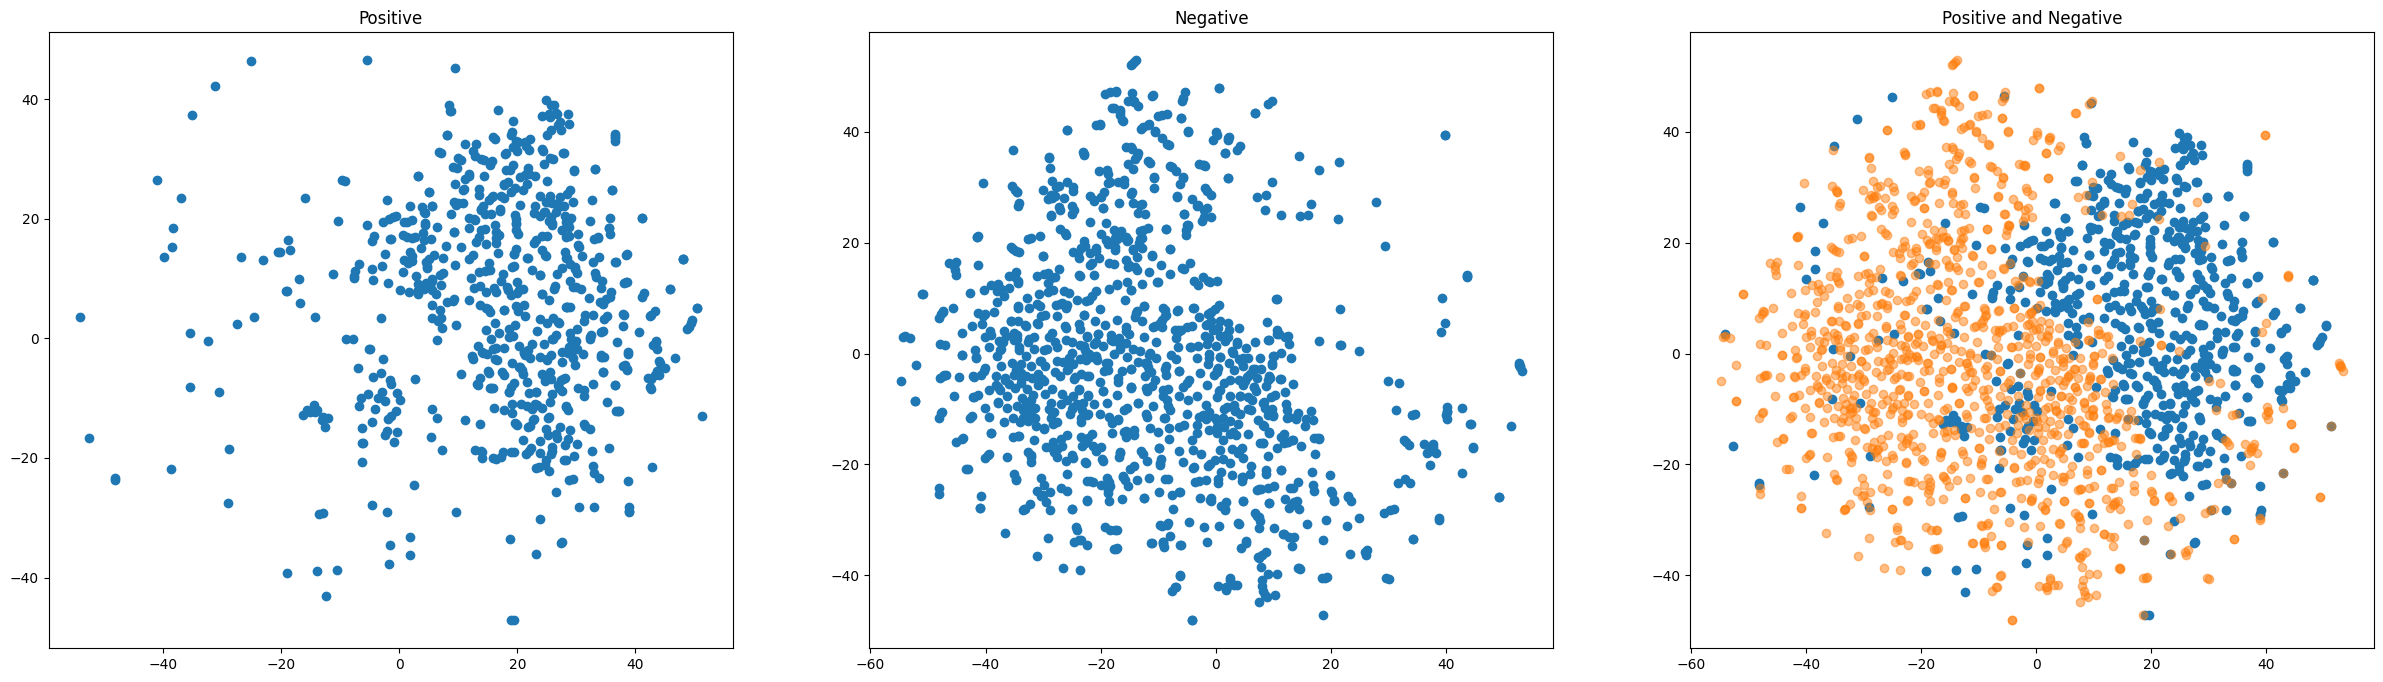

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30,8))
plt.subplot(131)
plt.scatter(X_LSTM[:len(L_POS),0], X_LSTM[:len(L_POS),1])
plt.title("Positive")
plt.subplot(132)
plt.scatter(X_LSTM[len(L_POS):,0], X_LSTM[len(L_POS):,1])
plt.title("Negative")
plt.subplot(133)
plt.scatter(X_LSTM[:len(L_POS),0], X_LSTM[:len(L_POS),1])
plt.scatter(X_LSTM[len(L_POS):,0], X_LSTM[len(L_POS):,1], alpha=0.5)
plt.title("Positive and Negative")
plt.show()


In [ ]:
import numpy as np
from sklearn.manifold import TSNE
X_dense = TSNE(n_components=2).fit_transform(emb_dense)


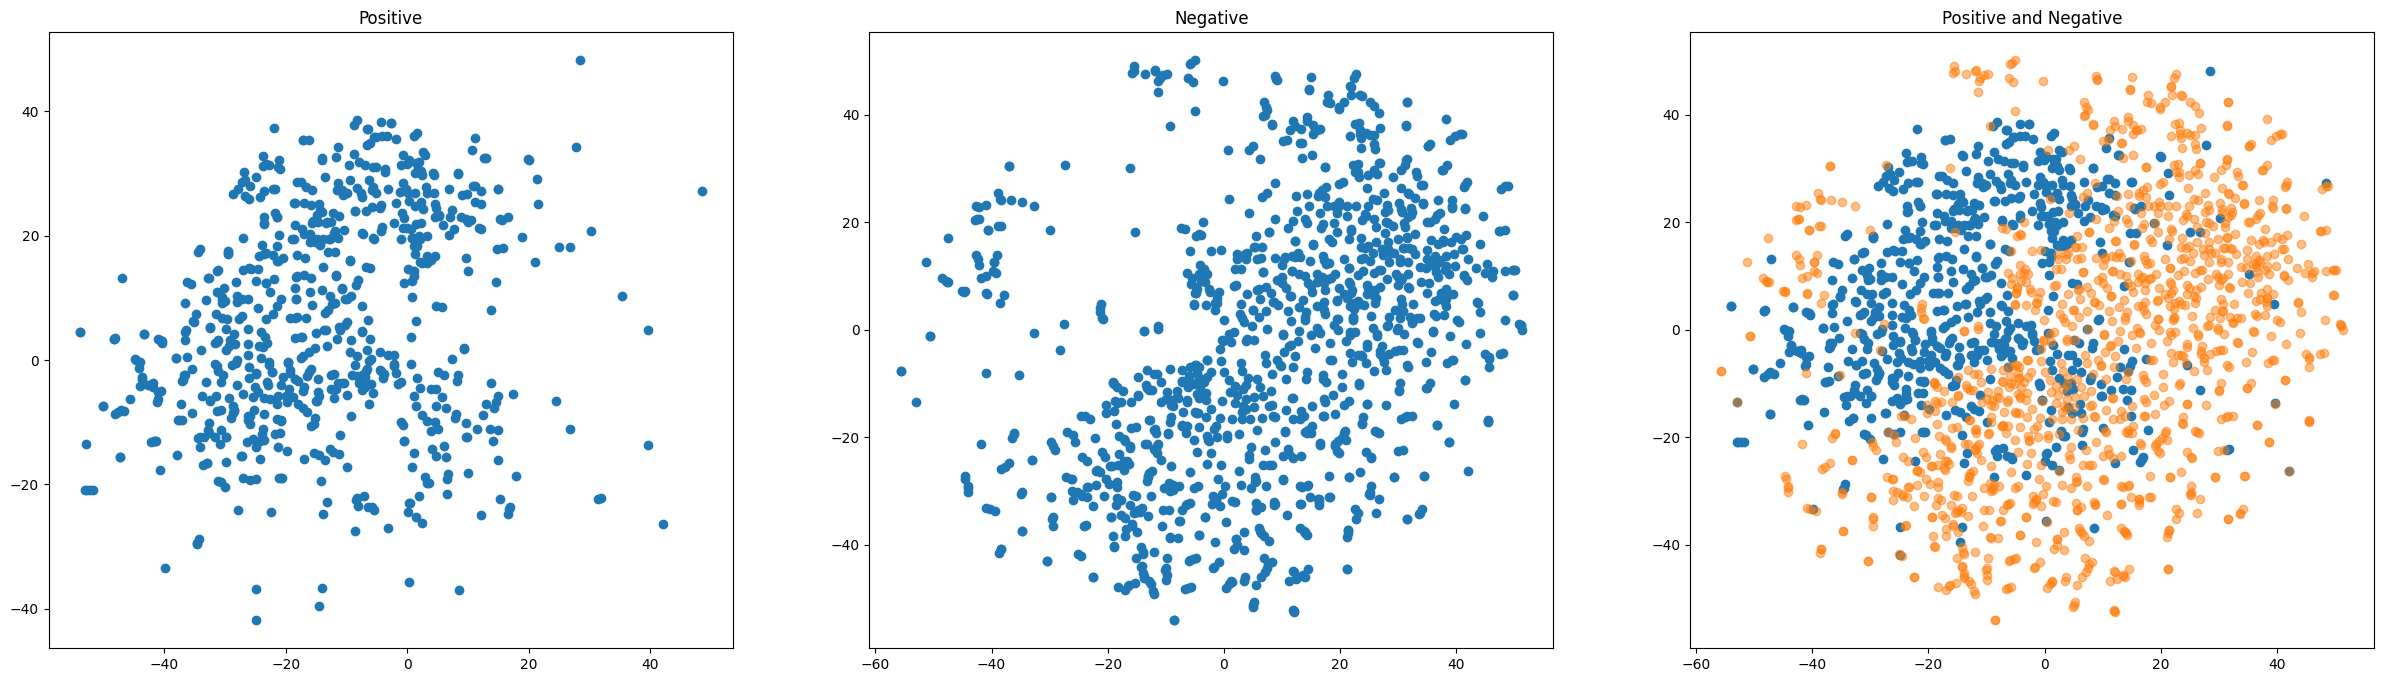

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30,8))
plt.subplot(131)
plt.scatter(X_dense[:len(L_POS),0], X_dense[:len(L_POS),1])
plt.title("Positive")
plt.subplot(132)
plt.scatter(X_dense[len(L_POS):,0], X_dense[len(L_POS):,1])
plt.title("Negative")
plt.subplot(133)
plt.scatter(X_dense[:len(L_POS),0], X_dense[:len(L_POS),1])
plt.scatter(X_dense[len(L_POS):,0], X_dense[len(L_POS):,1], alpha=0.5)
plt.title("Positive and Negative")
plt.show()


In [ ]:
import numpy as np
from sklearn.manifold import TSNE
X_glove = TSNE(n_components=2).fit_transform(emb_glove)


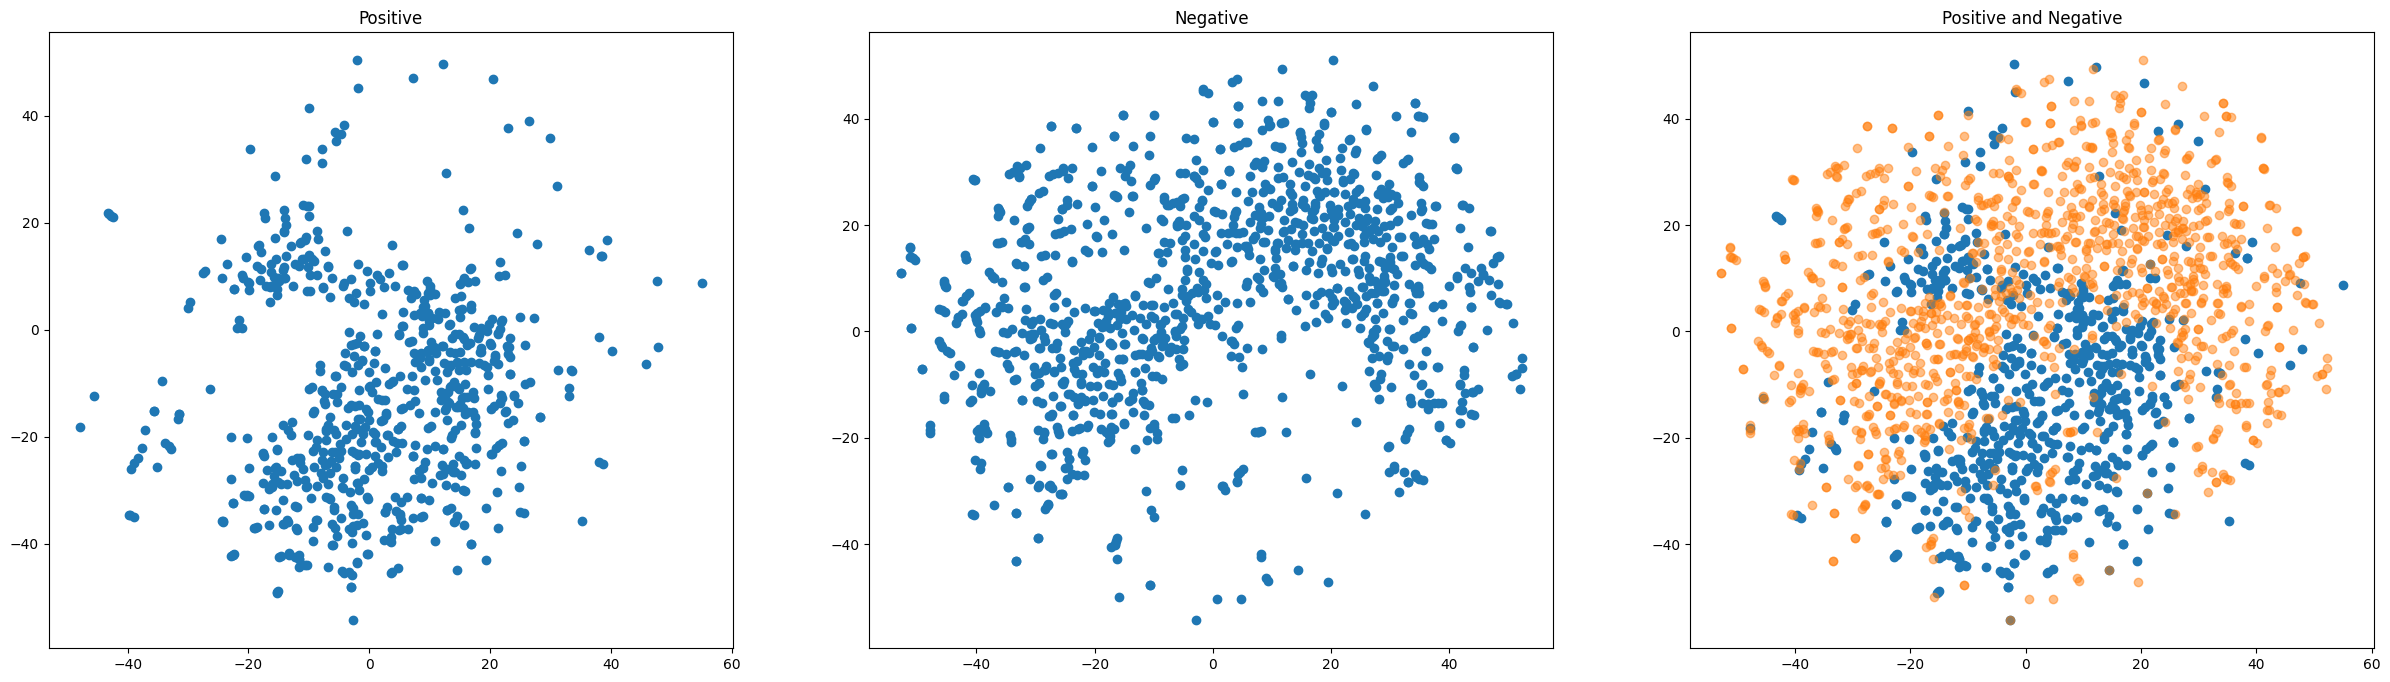

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30,8))
plt.subplot(131)
plt.scatter(X_glove[:len(L_POS),0], X_glove[:len(L_POS),1])
plt.title("Positive")
plt.subplot(132)
plt.scatter(X_glove[len(L_POS):,0], X_glove[len(L_POS):,1])
plt.title("Negative")
plt.subplot(133)
plt.scatter(X_glove[:len(L_POS),0], X_glove[:len(L_POS),1])
plt.scatter(X_glove[len(L_POS):,0], X_glove[len(L_POS):,1], alpha=0.5)
plt.title("Positive and Negative")
plt.show()


## 13. Class Separation Metric

Ratio of average cross-class distance to average within-class distance — lower is better separation.

In [ ]:
def class_dist(L_POS, L_NEG, embedding_matrix):
    def get_vec(word):
        if word in word_index and word_index[word] < max_words:
            return embedding_matrix[word_index[word]]
        return None
    pos_vecs = [get_vec(w) for w in L_POS if get_vec(w) is not None]
    neg_vecs = [get_vec(w) for w in L_NEG if get_vec(w) is not None]
    pos_vecs = np.array(pos_vecs)
    neg_vecs = np.array(neg_vecs)
    d12 = np.mean([
        np.linalg.norm(p - n)
        for p in pos_vecs for n in neg_vecs
    ])
    all_vecs = np.vstack((pos_vecs, neg_vecs))
    d = np.mean([
        np.linalg.norm(a - b)
        for i, a in enumerate(all_vecs)
        for j, b in enumerate(all_vecs)
        if i < j
    ])
    return d12 / d
def class_dist_glove():
    return class_dist(L_POS, L_NEG, embedding_matrix)
def class_dist_dense():
    return class_dist(L_POS, L_NEG, embedding_matrix1)
def class_dist_LSTM():
    return class_dist(L_POS, L_NEG, embedding_matrix2)
d_glove = class_dist_glove()
d_dense = class_dist_dense()
d_LSTM = class_dist_LSTM()


In [ ]:
print(d_glove, d_dense, d_LSTM)
print("Relative improvments:")
print("Dense:", (d_dense-d_glove)/d_glove*100)
print("LSTM:", (d_LSTM-d_glove)/d_glove*100)


1.009301743943346 1.010387 1.0096298
Relative improvments:
Dense: 0.10751986512504677
LSTM: 0.03250778846113197


Confirm the best embedding (LSTM-tuned) improves validation accuracy when used in the LSTM classifier.

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense
model = Sequential()
embedding_layer = Embedding(input_dim=max_words,
                            output_dim=embedding_dim,
                            weights=[embedding_matrix1],
                            trainable=False)
model.add(embedding_layer)
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - acc: 0.7842 - loss: 0.4646 - val_acc: 0.8356 - val_loss: 0.3914
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - acc: 0.8610 - loss: 0.3359 - val_acc: 0.8746 - val_loss: 0.3135
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - acc: 0.8879 - loss: 0.2839 - val_acc: 0.8802 - val_loss: 0.3027
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - acc: 0.9020 - loss: 0.2488 - val_acc: 0.8876 - val_loss: 0.2912
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.9104 - loss: 0.2318 - val_acc: 0.8888 - val_loss: 0.2861
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - acc: 0.9179 - loss: 0.2100 - val_acc: 0.8824 - val_loss: 0.3017
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - acc: 0.9221 - loss: 0.2011 - val_acc: 0.8922 - val_loss: 0.2937
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - acc: 0.9303 - loss: 0.1775 - val_acc: 0.8930 - val_loss: 0.2800
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

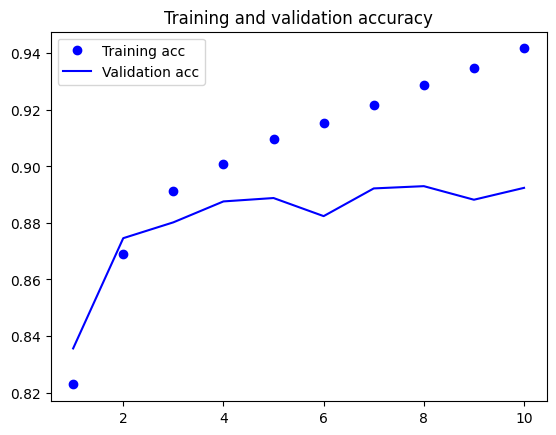

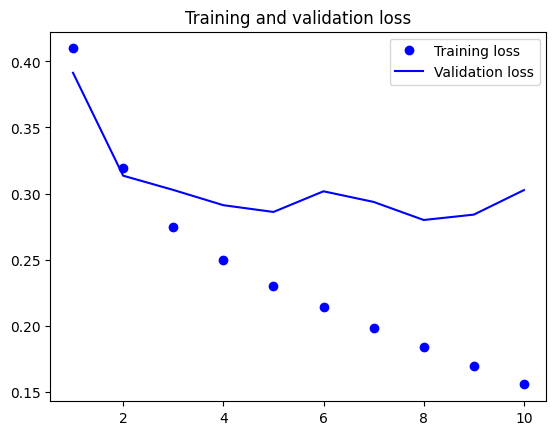

In [ ]:
plot_history(history)


## 14. Y-Network Architecture

Dual-input model: two parallel BiLSTM → Conv1D branches on the same review, concatenated before dense layers.

Both branches share architecture but have independent embedding layers for staged fine-tuning.

In [ ]:
from keras import backend as K
K.clear_session()


In [ ]:
import keras
from keras import layers
from keras import models
input_shape = (maxlen, )
left_inputs = layers.Input(shape=input_shape)
x = Embedding(max_words, embedding_dim, weights=[embedding_matrix1], trainable=False, input_length=maxlen)(left_inputs)
x = layers.Bidirectional(layers.LSTM(128, return_sequences = True))(x)
x = layers.Conv1D(64, 7, activation='relu')(x)
x = layers.GlobalMaxPool1D()(x)
right_inputs = layers.Input(shape=input_shape)
y = layers.Embedding(max_words, embedding_dim, weights=[embedding_matrix1], trainable=False, input_length=maxlen)(right_inputs)
y = layers.Bidirectional(LSTM(128, return_sequences = True))(y)
y = layers.Conv1D(64, 7, activation='relu')(y)
y = layers.GlobalMaxPool1D()(y)
x = layers.concatenate([x, y])
x = layers.Flatten()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model([left_inputs, right_inputs], outputs=outputs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 300)  │  3,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 500, 300)  │  3,000,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 500, 256)  │    439,296 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 500, 256)  │    439,296 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 494, 64)   │    114,752 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 494, 64)   │    114,752 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 128)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     66,048 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        513 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,174,657 (27.37 MB)

 Trainable params: 1,174,657 (4.48 MB)

 Non-trainable params: 6,000,000 (22.89 MB)

In [ ]:
callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,),
    keras.callbacks.ModelCheckpoint(filepath='LSTM_Conv1D.keras', monitor='val_loss', save_best_only=True,)]
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit([x_train, x_train], y_train, shuffle=True,
                    epochs=200,
                    batch_size=32,
                    callbacks=callbacks_list,
                    validation_data=([x_val, x_val], y_val))


Epoch 1/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - acc: 0.8198 - loss: 0.3794 - val_acc: 0.8810 - val_loss: 0.2771
Epoch 2/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - acc: 0.8995 - loss: 0.2428 - val_acc: 0.8944 - val_loss: 0.2613
Epoch 3/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - acc: 0.9273 - loss: 0.1877 - val_acc: 0.9004 - val_loss: 0.2514
Epoch 4/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - acc: 0.9426 - loss: 0.1441 - val_acc: 0.8948 - val_loss: 0.2698
Epoch 5/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - acc: 0.9647 - loss: 0.1000 - val_acc: 0.8958 - val_loss: 0.3236
Epoch 6/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - acc: 0.9798 - loss: 0.0603 - val_acc: 0.8954 - val_loss: 0.3698
Epoch 7/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - acc: 0.9883 - loss: 0.0369 - val_acc: 0.8956 - val_loss: 0.4430
Epoch 8/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - acc: 0.9892 - loss: 0.0318 - val_acc: 0.8958 - val_loss: 0.4772


In [ ]:
print(model.layers[3].name)


embedding_1


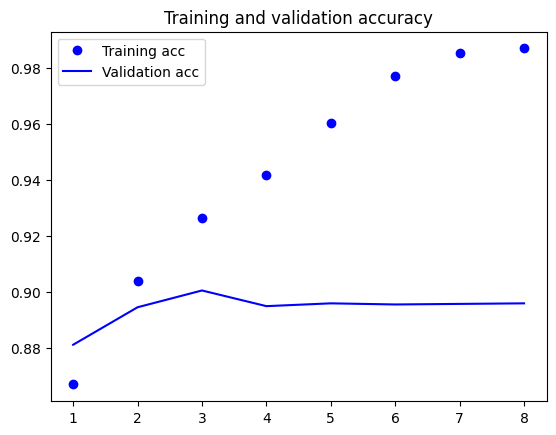

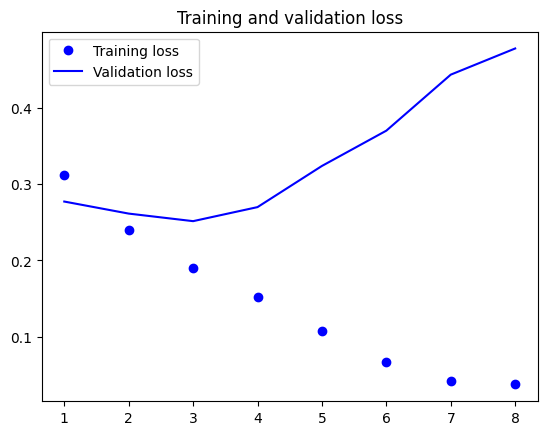

In [ ]:
plot_history(history)


### Phase 2: Fine-tune left-branch embedding

In [ ]:
model = keras.models.load_model('LSTM_Conv1D.keras')
for i in range(len(model.layers)):
    model.layers[i].trainable = False
model.layers[2].trainable = True
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['acc'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 300)  │  3,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 500, 300)  │  3,000,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 500, 256)  │    439,296 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 500, 256)  │    439,296 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 494, 64)   │    114,752 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 494, 64)   │    114,752 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 128)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     66,048 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        513 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,174,657 (27.37 MB)

 Trainable params: 3,000,000 (11.44 MB)

 Non-trainable params: 4,174,657 (15.93 MB)

In [ ]:
callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,),
    keras.callbacks.ModelCheckpoint(filepath='LSTM_Conv1D_retrain.keras', monitor='val_loss', save_best_only=True,)]
history = model.fit([x_train, x_train], y_train, shuffle=True,
                    epochs=200,
                    batch_size=32,
                    callbacks=callbacks_list,
                    validation_data=([x_val, x_val], y_val))


Epoch 1/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 72ms/step - acc: 0.9541 - loss: 0.1321 - val_acc: 0.9062 - val_loss: 0.2336
Epoch 2/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - acc: 0.9789 - loss: 0.0835 - val_acc: 0.9038 - val_loss: 0.2394
Epoch 3/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - acc: 0.9897 - loss: 0.0550 - val_acc: 0.9054 - val_loss: 0.2451
Epoch 4/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - acc: 0.9947 - loss: 0.0388 - val_acc: 0.9044 - val_loss: 0.2536
Epoch 5/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - acc: 0.9972 - loss: 0.0278 - val_acc: 0.9034 - val_loss: 0.2614
Epoch 6/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - acc: 0.9991 - loss: 0.0201 - val_acc: 0.9022 - val_loss: 0.2695


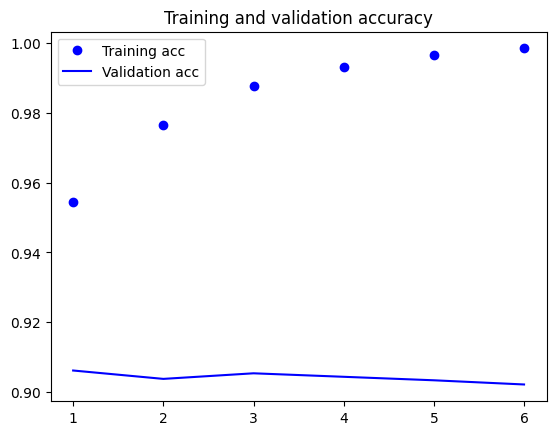

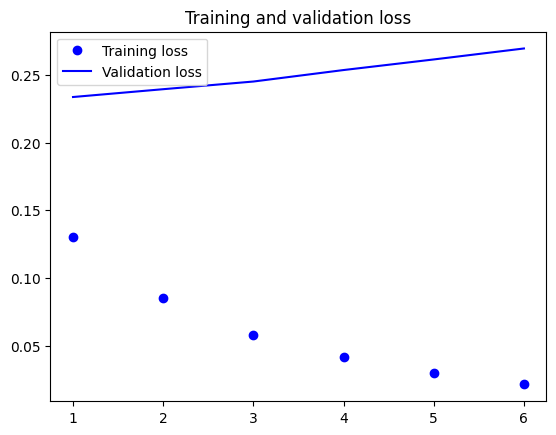

In [ ]:
plot_history(history)


### Phase 3: Fine-tune right-branch embedding

In [ ]:
model = keras.models.load_model('LSTM_Conv1D_retrain.keras')
for i in range(len(model.layers)):
    model.layers[i].trainable = False
model.layers[3].trainable = True
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['acc'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 300)  │  3,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 500, 300)  │  3,000,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 500, 256)  │    439,296 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 500, 256)  │    439,296 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 494, 64)   │    114,752 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 494, 64)   │    114,752 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 128)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     66,048 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        513 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,174,657 (27.37 MB)

 Trainable params: 3,000,000 (11.44 MB)

 Non-trainable params: 4,174,657 (15.93 MB)

In [ ]:
callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,),
    keras.callbacks.ModelCheckpoint(filepath='LSTM_Conv1D_retrain_1.keras', monitor='val_loss', save_best_only=True,)]
history = model.fit([x_train, x_train], y_train, shuffle=True,
                    epochs=200,
                    batch_size=32,
                    callbacks=callbacks_list,
                    validation_data=([x_val, x_val], y_val))


Epoch 1/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 72ms/step - acc: 0.9769 - loss: 0.0821 - val_acc: 0.9084 - val_loss: 0.2350
Epoch 2/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - acc: 0.9881 - loss: 0.0530 - val_acc: 0.9098 - val_loss: 0.2460
Epoch 3/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - acc: 0.9938 - loss: 0.0356 - val_acc: 0.9086 - val_loss: 0.2583
Epoch 4/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - acc: 0.9968 - loss: 0.0242 - val_acc: 0.9050 - val_loss: 0.2709
Epoch 5/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - acc: 0.9980 - loss: 0.0178 - val_acc: 0.9064 - val_loss: 0.2815
Epoch 6/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - acc: 0.9990 - loss: 0.0124 - val_acc: 0.9034 - val_loss: 0.2967


## 15. Final Test Evaluation

Load the best checkpoint and evaluate on held-out IMDB test reviews.

In [ ]:
model = keras.models.load_model('LSTM_Conv1D_retrain_1.keras')


In [ ]:
test_dir = os.path.join(imdb_dir, 'test')
labels = []
texts = []
for label_type in ['neg', 'pos']:
    dir_name = os.path.join(test_dir, label_type)
    for fname in sorted(os.listdir(dir_name)):
        if fname[-4:] == '.txt':
            f = open(os.path.join(dir_name, fname))
            texts.append(f.read())
            f.close()
            if label_type == 'neg':
                labels.append(0)
            else:
                labels.append(1)
sequences = tokenizer.texts_to_sequences(texts)
x_test = pad_sequences(sequences, maxlen=maxlen)
y_test = np.asarray(labels)


In [ ]:
model.evaluate([x_test, x_test], y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - acc: 0.9149 - loss: 0.2195


[0.2298915982246399, 0.9093999862670898]

**Result:** test accuracy exceeds 90% using staged embedding fine-tuning with early stopping.